Exercise2: Binary Classification

In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
torch.__version__

'2.13.0+rocm10.0.0'

In [3]:
from sklearn.datasets import make_moons

X,y= make_moons(n_samples=1000,
                noise=0.07,
                random_state=42)


In [4]:
X[:5],y[:5], X.shape, y.shape

(array([[-0.03341062,  0.4213911 ],
        [ 0.99882703, -0.4428903 ],
        [ 0.88959204, -0.32784256],
        [ 0.34195829, -0.41768975],
        [-0.83853099,  0.53237483]]),
 array([1, 1, 1, 1, 0]),
 (1000, 2),
 (1000,))

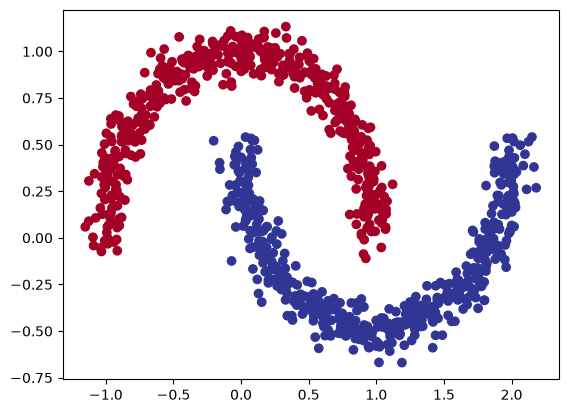

In [5]:
# Visualize the data on a plot
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu);

In [6]:
#convert data into tensors from numpy
X=torch.from_numpy(X).type(torch.float)
y=torch.from_numpy(y).type(torch.float)

In [7]:
X[:5],y[:5], X.shape, y.shape

(tensor([[-0.0334,  0.4214],
         [ 0.9988, -0.4429],
         [ 0.8896, -0.3278],
         [ 0.3420, -0.4177],
         [-0.8385,  0.5324]]),
 tensor([1., 1., 1., 1., 0.]),
 torch.Size([1000, 2]),
 torch.Size([1000]))

In [8]:
#Split the data
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,train_size=0.8,random_state=42
)

In [9]:
X_train[:5],X_test[:5],y_train[:5],y_test[:5]

(tensor([[ 2.0144,  0.2466],
         [-1.0187,  0.4045],
         [-0.1252,  1.0580],
         [-0.0977,  0.9901],
         [ 0.3807, -0.2384]]),
 tensor([[ 0.5425, -0.3964],
         [ 0.8411,  0.6354],
         [ 1.2745, -0.4373],
         [ 0.6870,  0.8720],
         [ 1.8176, -0.1365]]),
 tensor([1., 0., 0., 0., 1.]),
 tensor([1., 0., 1., 0., 1.]))

In [10]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

In [ ]:
from torch import nn

class binaryclassifier(nn.Module):
    def __init__(self,in_features=2,hidden_features1=16,hidden_features2=8,out_features=1):
        super().__init__()
        self.layer1=nn.Linear(in_features=in_features,out_features=hidden_features1)
        self.layer2=nn.Linear(in_features=hidden_features1,out_features=hidden_features2)
        self.layer3=nn.Linear(in_features=hidden_features2,out_features=out_features)
        self.relu=nn.ReLU()
        #self.sigmoid=nn.Sigmoid()
    def forward(self,X):
        #return self.sigmoid(self.layer3(self.relu(self.layer2(self.relu(self.layer1(X))))))
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(X)))))

In [12]:
model1=binaryclassifier()
model1

binaryclassifier(
  (layer1): Linear(in_features=2, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (layer3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
)

In [13]:
model1.state_dict()

OrderedDict([('layer1.weight',
              tensor([[-0.5591, -0.1114],
                      [-0.1198,  0.5292],
                      [ 0.3867, -0.0624],
                      [-0.0249,  0.6716],
                      [ 0.3243,  0.2539],
                      [-0.3855, -0.5199],
                      [-0.3115,  0.2241],
                      [ 0.2174,  0.2949],
                      [ 0.5945, -0.6918],
                      [-0.5609, -0.1804],
                      [ 0.0876, -0.0077],
                      [ 0.4703, -0.1464],
                      [ 0.0130,  0.2927],
                      [-0.5234,  0.1543],
                      [ 0.0487,  0.0407],
                      [ 0.3301,  0.1479]])),
             ('layer1.bias',
              tensor([-0.4965,  0.5650,  0.6411, -0.1979, -0.3029, -0.6145, -0.5294, -0.1939,
                       0.0935, -0.7045, -0.2230, -0.2612,  0.0382, -0.1872,  0.4152, -0.3514])),
             ('layer2.weight',
              tensor([[-0.2201, -0.1335, -0

In [14]:
loss_fn=nn.BCEWithLogitsLoss()
optimizer=torch.optim.AdamW(params=model1.parameters(),
                            lr=0.1)


In [15]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
AMD Radeon 8060S Graphics


In [16]:
device=torch.device("cuda" if torch.cuda.is_available else "cpu")

model1=model1.to(device)
X_train=X_train.to(device)
X_test=X_test.to(device)
y_train=y_train.to(device)
y_test=y_test.to(device)

In [17]:
print("Model1:", next(model1.parameters()).device)
print("X_train:", X_train.device)
print("X_test:", X_test.device)
print("y_train:", y_train.device)
print("y_test:", y_test.device)

Model1: cuda:0
X_train: cuda:0
X_test: cuda:0
y_train: cuda:0
y_test: cuda:0


In [18]:
epochs=1000

for epoch in range(epochs):
    epoch+=1
    model1.train()
    y_preds=model1(X_train).squeeze()
    loss=loss_fn(y_preds,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model1.eval()
    with torch.inference_mode():
        y_preds_test=model1(X_test).squeeze()
        loss_test=loss_fn(y_preds_test,y_test)
    
    if epoch % 100==0:
        print(f"Epochs: {epoch} | Training Loss: {loss} | Testing_loss: {loss_test}")


Epochs: 100 | Training Loss: 0.00023844225506763905 | Testing_loss: 0.00011469595483504236
Epochs: 200 | Training Loss: 0.00024879153352230787 | Testing_loss: 0.00017111009219661355
Epochs: 300 | Training Loss: 0.0001838593016145751 | Testing_loss: 0.0001332469255430624
Epochs: 400 | Training Loss: 0.00015328035806305707 | Testing_loss: 0.00010952058801194653
Epochs: 500 | Training Loss: 0.0001343282056041062 | Testing_loss: 9.614252485334873e-05
Epochs: 600 | Training Loss: 0.00011483678099466488 | Testing_loss: 8.205763879232109e-05
Epochs: 700 | Training Loss: 9.88948013400659e-05 | Testing_loss: 7.069656567182392e-05
Epochs: 800 | Training Loss: 8.594143582740799e-05 | Testing_loss: 6.196810136316344e-05
Epochs: 900 | Training Loss: 7.525809633079916e-05 | Testing_loss: 5.462059561978094e-05
Epochs: 1000 | Training Loss: 6.636043690377846e-05 | Testing_loss: 4.758064460474998e-05


In [19]:
model1.eval()

with torch.inference_mode():
    y_logits = model1(X_test).squeeze()
    y_probs = torch.sigmoid(y_logits)
    y_pred = (y_probs >= 0.5).float()

accuracy = (y_pred == y_test).float().mean()

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 1.0000


In [20]:
y_pred[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.], device='cuda:0'))

In [21]:
import requests
from pathlib import Path 

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists, skipping download


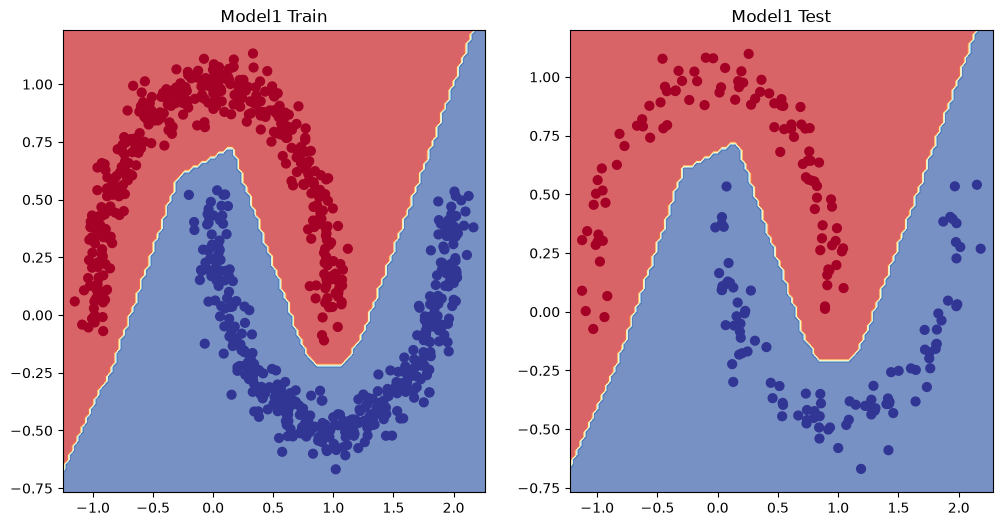

In [22]:
# Plot decision boundaries for training and test sets
import matplotlib.pyplot as plt
from helper_functions import plot_decision_boundary, plot_predictions

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Model1 Train")
plot_decision_boundary(model1, X_train, y_train) # model1 = no non-linearity
plt.subplot(1, 2, 2)
plt.title("Model1 Test")
plot_decision_boundary(model1, X_test, y_test) # model2 = has non-linearity